In [26]:
## Predictive Logistics Intelligence System Using Random Forest, Deep Learning and Groq LLM
# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# 2. Dataset Loading and Understanding

In [2]:
df = pd.read_csv('logistics.csv')
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [ ]:
# 3. Data Preprocessing

In [4]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Warehouse_block'] = le.fit_transform(df['Warehouse_block'])
df['Mode_of_Shipment'] = le.fit_transform(df['Mode_of_Shipment'])
df['Product_importance'] = le.fit_transform(df['Product_importance'])
df['Gender'] = le.fit_transform(df['Gender'])

# Features & Target
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

print("✅ Preprocessing Done!")
print("Features shape:", X.shape)

✅ Preprocessing Done!
Features shape: (10999, 10)


In [32]:
# 4. Machine Learning Model (Voting classifier)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Voting Classifier - Random Forest + SVM
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(probability=True, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('svm', svm)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.665
              precision    recall  f1-score   support

           0       0.59      0.61      0.60       895
           1       0.72      0.71      0.71      1305

    accuracy                           0.67      2200
   macro avg       0.65      0.66      0.65      2200
weighted avg       0.67      0.67      0.67      2200



In [7]:
print("X_train :", 'X_train' in globals())
print("X_train_scaled :", 'X_train_scaled' in globals())
print("X_test_scaled :", 'X_test_scaled' in globals())

X_train : True
X_train_scaled : False
X_test_scaled : False


In [ ]:
# 5. Data scaling for Deep Learning

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8799, 10)
(2200, 10)


In [ ]:
# 6. Deep learning Model

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

history = dl_model.fit(X_train_scaled, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

loss, acc = dl_model.evaluate(X_test_scaled, y_test, verbose=0)
print("DL Accuracy:", round(acc, 4))

C:\Users\kirut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DL Accuracy: 0.6777


In [ ]:
# 7. Feature Importance Analysis

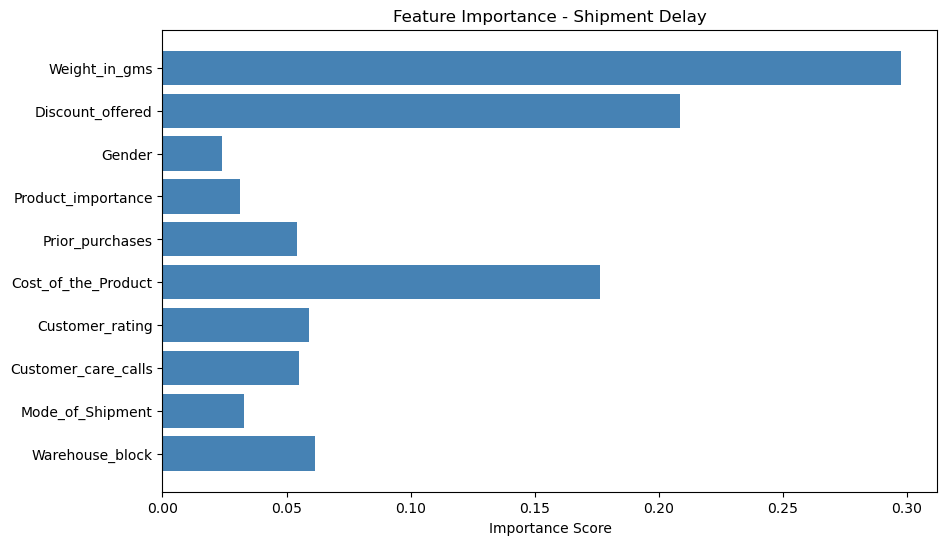

In [10]:
import matplotlib.pyplot as plt

rf.fit(X_train_scaled, y_train)
importance = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance, color='steelblue')
plt.title('Feature Importance - Shipment Delay')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# 8.Groq LLM Integration

In [11]:
!pip install groq


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from groq import Groq

client = Groq(api_key="YOUR_PASS_KEY")

def get_shipment_advice(row):
    prompt = f"""
    You are a logistics expert.
    Analyze this shipment and give advice:
    
    Warehouse Block: {row['Warehouse_block']}
    Mode of Shipment: {row['Mode_of_Shipment']}
    Weight: {row['Weight_in_gms']}g
    Discount: {row['Discount_offered']}%
    Customer Rating: {row['Customer_rating']}
    Delay Predicted: {'Yes' if row['Reached.on.Time_Y.N']==0 else 'No'}
    
    Give 3 specific recommendations to prevent delay.
    """
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# Test
shipment = df.iloc[0]
print(get_shipment_advice(shipment))

As a logistics expert, I'll analyze the given shipment details and provide recommendations to prevent delays.

**Analysis:**
The shipment is from Warehouse Block 3, with a mode of shipment coded as 0 (which might indicate a standard or default shipping method). The weight is 1233g, and a discount of 44% has been applied. The customer rating is 2, which might indicate some level of dissatisfaction or concern. However, there is no predicted delay at this time.

**Recommendations to Prevent Delay:**

1. **Verify Warehouse Block 3's Efficiency**: Ensure that Warehouse Block 3 is operating at optimal levels, with adequate staffing, and streamlined processes. This will help prevent any potential bottlenecks or inefficiencies that could lead to delays. I recommend conducting a quick audit to confirm that all systems are in place and functioning correctly.
2. **Review and Validate Shipping Method (Mode 0)**: Although the mode of shipment is coded as 0, it's essential to review and validate the

In [44]:
# 9. Project Conclusion

In [3]:
print(""" PROJECT CONCLUSION
 1.This project successfully predicts shipment delays using Machine Learning and Deep Learning techniques. A Voting Classifier model combining
Random Forest and SVM was used for shipment delay prediction, while a Deep Learning Neural Network was developed for performance comparison.

 2.Feature importance analysis helped identify the key factors affecting shipment delays, such as product weight, discount offered, and product cost.
To improve interpretability, Groq LLM was integrated to generate intelligent recommendations and preventive actions based on shipment details.

 3.Overall this project demonstrates how predictive analytics and Large Language Models (LLMs) can be combined to support logistics decision-making, 
reduce delivery delays, and improve supply chain efficiency.""")

 PROJECT CONCLUSION
 1.This project successfully predicts shipment delays using Machine Learning and Deep Learning techniques. A Voting Classifier model combining
Random Forest and SVM was used for shipment delay prediction, while a Deep Learning Neural Network was developed for performance comparison.

 2.Feature importance analysis helped identify the key factors affecting shipment delays, such as product weight, discount offered, and product cost.
To improve interpretability, Groq LLM was integrated to generate intelligent recommendations and preventive actions based on shipment details.

 3.Overall this project demonstrates how predictive analytics and Large Language Models (LLMs) can be combined to support logistics decision-making, 
reduce delivery delays, and improve supply chain efficiency.
